In [1]:
import numpy as np
import matplotlib . pyplot as plt

In [2]:

np. random . seed (2025)
n, p, k = 500 , 50, 8
sigma = 1.0

m = 10
Z = np. random . randn (n, m)
A = np. random . randn (m, p) * 0.8
X = Z.dot(A) + 0.1 * np. random . randn (n, p)

w_true = np. zeros (p)
w_true [:k] = np. linspace (5.0 , 1.0 , k) * np. random . choice ([1 , -1], k)
y = X.dot( w_true ) + sigma * np. random . randn (n)

idx = np. random . permutation (n)
train_idx , test_idx = idx [:350] , idx [350:]
X_train , y_train = X[ train_idx ], y[ train_idx ]
X_test , y_test = X[ test_idx ], y[ test_idx ]



In [8]:
def ridge_closed_form (X, y, lam):
    n_features = X.shape[1]
    I = np.eye(n_features)
    w = np.linalg.inv(X.T @ X + lam * I) @ X.T @ y
    return w

def ridge_objective (X, y, w, lam):
    residual = X @ w - y
    return np.dot(residual, residual) + lam * np.dot(w, w)

def ridge_grad (X, y, w, lam):
    return 2 * (X.T @ (X @ w - y) + lam * w)

def gradient_descent (X, y, lam , s, alpha , beta ):
    w = np.zeros(X.shape[1])
    obj_values = []

    for _ in range(1000):
        grad = ridge_grad(X, y, w, lam)
        t = s
        # Armijo condition
        while ridge_objective(X, y, w - t*grad, lam) > ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta  # shrink step size
        w = w - t * grad
        obj_values.append(ridge_objective(X, y, w, lam))
    return w, obj_values

In [8]:
w_closed = ridge_closed_form(X_train, y_train, lam=1.0)
w_gd, obj_history = gradient_descent(X_train, y_train, lam=1.0, s=1e-3, alpha=0.5, beta=0.8)

In [9]:
print("Closed-form weights:", w_closed[:5])
print("Gradient descent weights:", w_gd[:5])

Closed-form weights: [ 4.4339107  -3.47288706 -3.63994043  2.75972927  1.7996845 ]
Gradient descent weights: [ 2.82311265 -2.27692212 -2.22058454  2.03624335  1.25303268]


In [10]:
lam = 1.0
w_closed = ridge_closed_form(X_train, y_train, lam)
w_gd, obj_history = gradient_descent(X_train, y_train, lam, s=1e-3, alpha=0.5, beta=0.8)

print("Closed-form and Gradient Descent weights are similar:", np.allclose(w_closed, w_gd, atol=1e-2))

Closed-form and Gradient Descent weights are similar: False


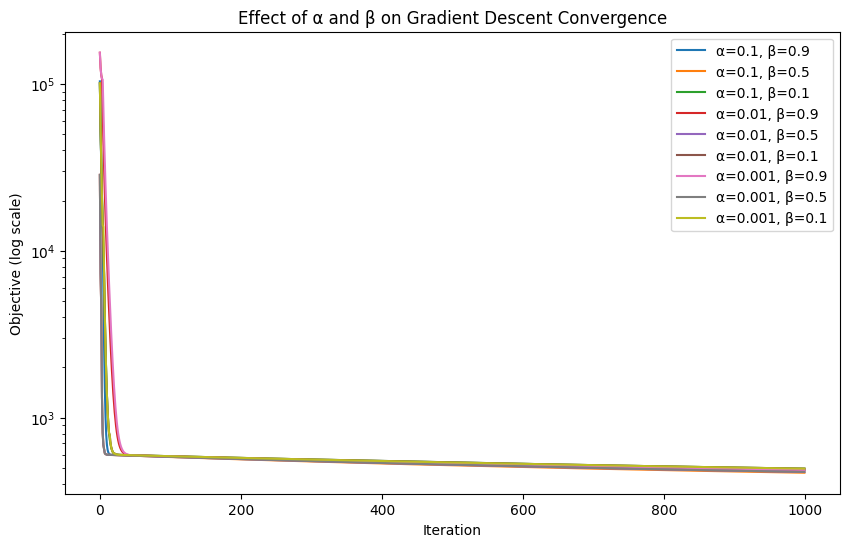

In [10]:

lam = 1.0
s = 1.0  # initial step size

alpha_values = [1e-1, 1e-2, 1e-3]
beta_values = [0.9, 0.5, 0.1]

results = {}

for alpha in alpha_values:
    for beta in beta_values:
        w_gd, obj_values = gradient_descent(X_train, y_train, lam, s, alpha, beta)
        results[(alpha, beta)] = obj_values

# Plot objective convergence
plt.figure(figsize=(10,6))
for (alpha, beta), obj_values in results.items():
    plt.plot(obj_values, label=f"α={alpha}, β={beta}")

plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Objective (log scale)')
plt.title('Effect of α and β on Gradient Descent Convergence')
plt.legend()
plt.show()

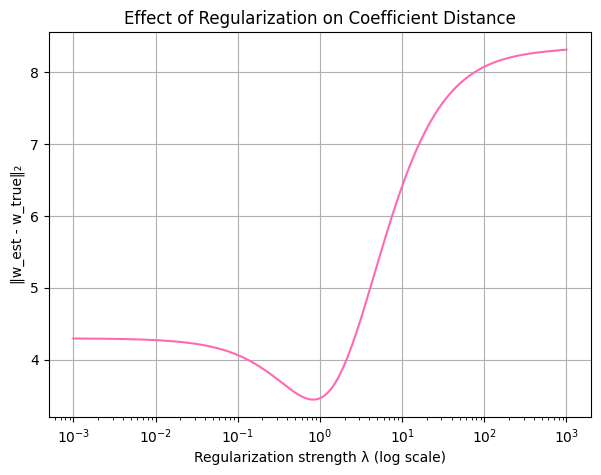

In [19]:
lambdas = np.logspace(-3, 3, 1000)  # λ values from 0.001 to 1000
distances = []

for lam in lambdas:
    w_est = ridge_closed_form(X_train, y_train, lam)
    dist = np.linalg.norm(w_est - w_true)  # Euclidean (L2) distance
    distances.append(dist)

# --- Plot ---
plt.figure(figsize=(7,5))
plt.semilogx(lambdas, distances,  color='hotpink')
plt.xlabel('Regularization strength λ (log scale)')
plt.ylabel('‖w_est - w_true‖₂')
plt.title('Effect of Regularization on Coefficient Distance')
plt.grid(True)
plt.show()

usually correct procedure to normalize data
scale
MSE

α=0.1, β=0.9, final objective=485.3590
α=0.1, β=0.5, final objective=467.1852
α=0.1, β=0.1, final objective=494.1746
α=0.01, β=0.9, final objective=485.6265
α=0.01, β=0.5, final objective=472.0334
α=0.01, β=0.1, final objective=494.1746
α=0.001, β=0.9, final objective=485.6265
α=0.001, β=0.5, final objective=472.4966
α=0.001, β=0.1, final objective=494.1746


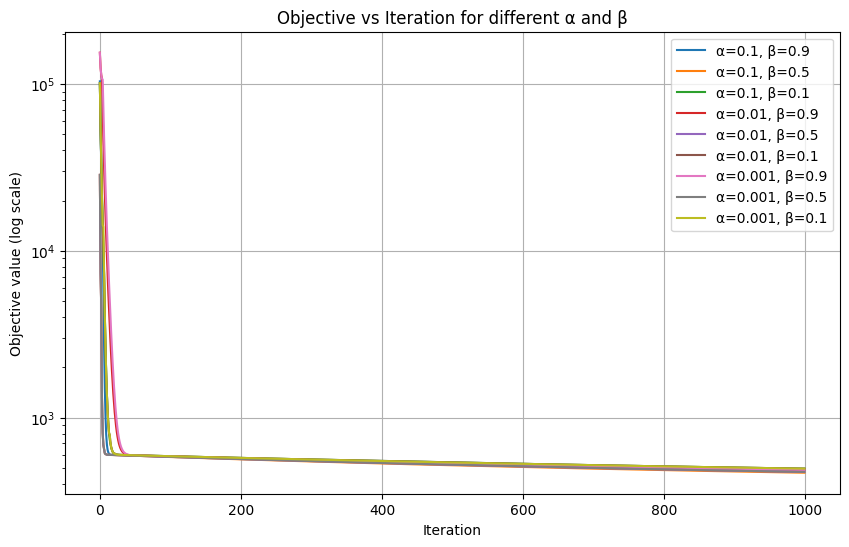

In [21]:
lam = 1.0   # regularization strength
s = 1.0     # initial step size

alpha_values = [1e-1, 1e-2, 1e-3]
beta_values = [0.9, 0.5, 0.1]

results = {}

for alpha in alpha_values:
    for beta in beta_values:
        w_gd, obj_values = gradient_descent(X_train, y_train, lam, s, alpha, beta)
        results[(alpha, beta)] = obj_values
        print(f"α={alpha}, β={beta}, final objective={obj_values[-1]:.4f}")

        
plt.figure(figsize=(10, 6))

for (alpha, beta), obj_values in results.items():
    label = f"α={alpha}, β={beta}"
    plt.plot(obj_values, label=label)

plt.yscale('log')  # objectives typically decrease exponentially
plt.xlabel('Iteration')
plt.ylabel('Objective value (log scale)')
plt.title('Objective vs Iteration for different α and β')
plt.legend()
plt.grid(True)
plt.show()

α=0.9, β=0.9, final objective=386.0581
α=0.9, β=0.5, final objective=448.0272
α=0.9, β=0.1, final objective=494.4159
α=0.9, β=0.01, final objective=552.8463
α=0.5, β=0.9, final objective=379.9709
α=0.5, β=0.5, final objective=464.8510
α=0.5, β=0.1, final objective=494.1746
α=0.5, β=0.01, final objective=585.0951
α=0.1, β=0.9, final objective=485.3590
α=0.1, β=0.5, final objective=467.1852
α=0.1, β=0.1, final objective=494.1746
α=0.1, β=0.01, final objective=585.0951
α=0.01, β=0.9, final objective=485.6265
α=0.01, β=0.5, final objective=472.0334
α=0.01, β=0.1, final objective=494.1746
α=0.01, β=0.01, final objective=585.0951


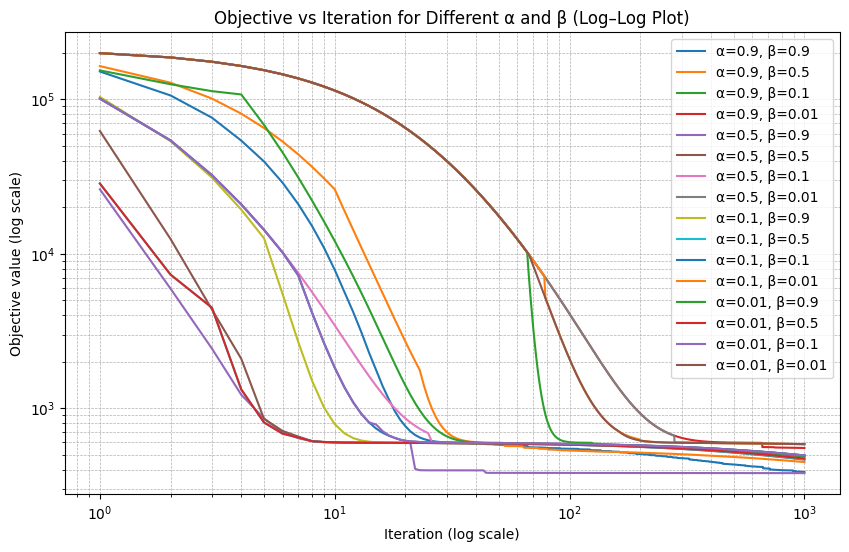

In [24]:

lam = 1.0   # regularization strength
s = 1.0     # initial step size

alpha_values = [0.9, 0.5, 0.1, 0.01]
beta_values = [0.9, 0.5, 0.1, 0.01]

results = {}

for alpha in alpha_values:
    for beta in beta_values:
        w_gd, obj_values = gradient_descent(X_train, y_train, lam, s, alpha, beta)
        results[(alpha, beta)] = obj_values
        print(f"α={alpha}, β={beta}, final objective={obj_values[-1]:.4f}")

# --- Plot ---
plt.figure(figsize=(10,6))

for (alpha, beta), obj_values in results.items():
    label = f"α={alpha}, β={beta}"
    iterations = np.arange(1, len(obj_values) + 1)
    plt.plot(iterations, obj_values, label=label)

plt.xscale('log')   # <-- Logarithmic x-axis (iterations)
plt.yscale('log')   # <-- Logarithmic y-axis (objective values)
plt.xlabel('Iteration (log scale)')
plt.ylabel('Objective value (log scale)')
plt.title('Objective vs Iteration for Different α and β (Log–Log Plot)')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

α=0.9, β=0.9, final objective=386.0581
α=0.9, β=0.5, final objective=448.0272
α=0.9, β=0.1, final objective=494.4159
α=0.9, β=0.01, final objective=552.8463
α=0.5, β=0.9, final objective=379.9709
α=0.5, β=0.5, final objective=464.8510
α=0.5, β=0.1, final objective=494.1746
α=0.5, β=0.01, final objective=585.0951
α=0.1, β=0.9, final objective=485.3590
α=0.1, β=0.5, final objective=467.1852
α=0.1, β=0.1, final objective=494.1746
α=0.1, β=0.01, final objective=585.0951
α=0.01, β=0.9, final objective=485.6265
α=0.01, β=0.5, final objective=472.0334
α=0.01, β=0.1, final objective=494.1746
α=0.01, β=0.01, final objective=585.0951


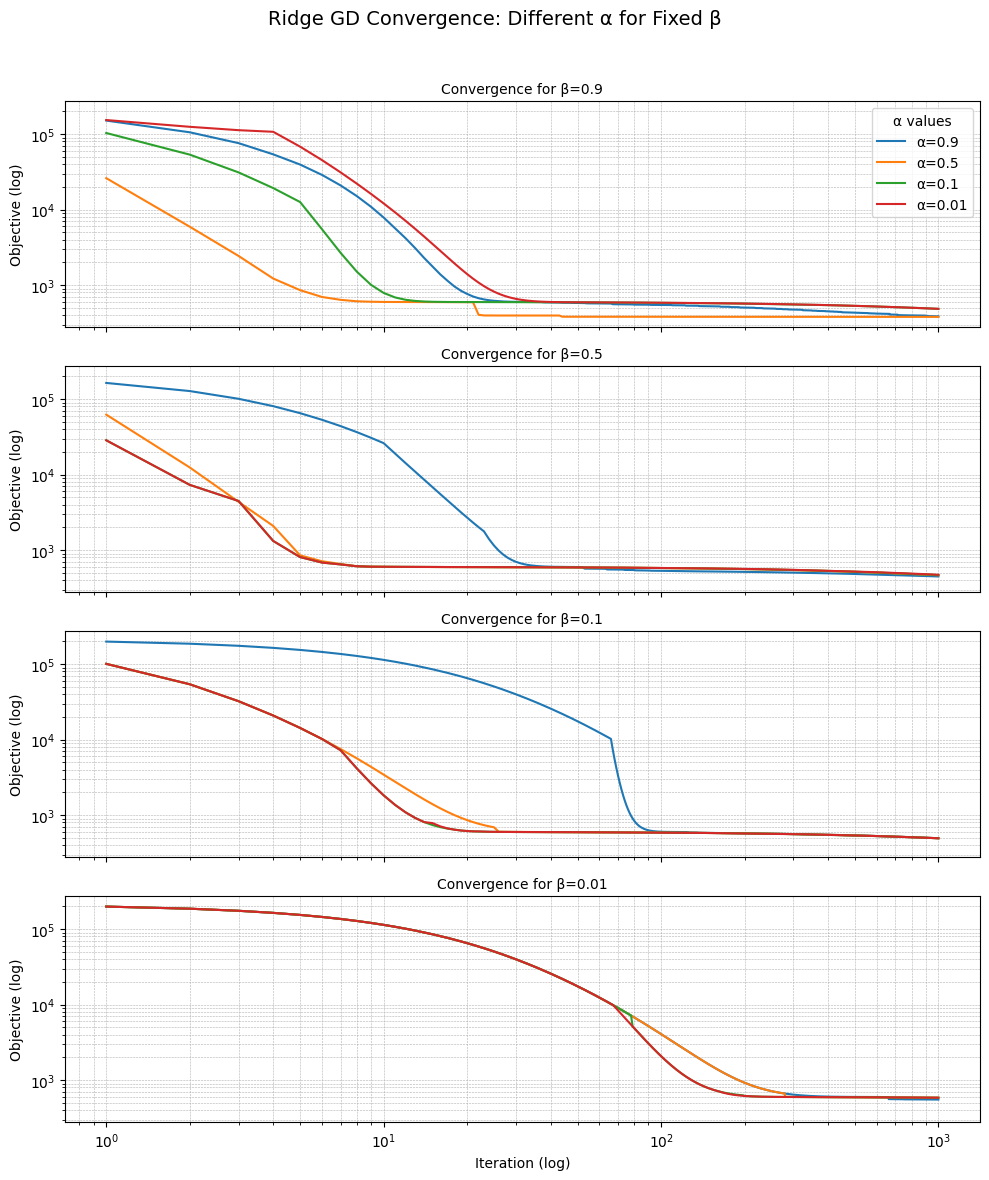

In [ ]:
lam = 1.0   # regularization strength
s = 1.0     # initial step size
 
alpha_values = [0.9, 0.5, 0.1, 0.01]
beta_values  = [0.9, 0.5, 0.1, 0.01]

# Store results for each (alpha, beta)
results = {}
for alpha in alpha_values:
    for beta in beta_values:
        w_gd, obj_values = gradient_descent(X_train, y_train, lam, s, alpha, beta)
        results[(alpha, beta)] = obj_values
        print(f"α={alpha}, β={beta}, final objective={obj_values[-1]:.4f}")

# === Plot convergence curves: Rows = β, curves per row = α ===
fig, axes = plt.subplots(len(beta_values), 1, figsize=(10, 12), sharex=True, sharey=True)

for i, beta in enumerate(beta_values):
    ax = axes[i]
    for alpha in alpha_values:
        iterations = np.arange(1, len(results[(alpha, beta)]) + 1)
        obj_values = results[(alpha, beta)]
        ax.plot(iterations, obj_values, label=f"α={alpha}")
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f"Convergence for β={beta}", fontsize=10)
    ax.grid(True, which='both', ls='--', lw=0.4)
    ax.set_ylabel('Objective (log)')

axes[-1].set_xlabel('Iteration (log)')
axes[0].legend(title="α values", loc='upper right')
plt.suptitle("Ridge GD Convergence: Different α for Fixed β", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

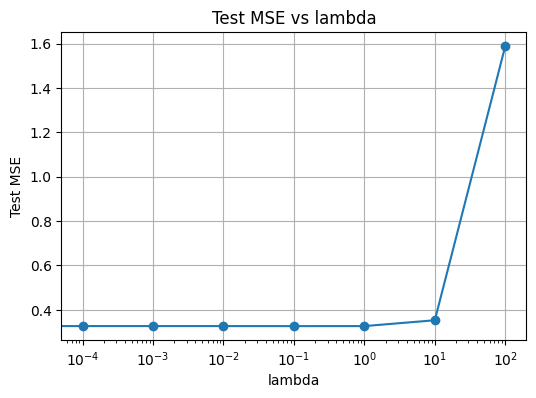

In [19]:
# plot test MSE vs lambda
plt.figure(figsize=(6,4))
plt.plot(lam_list, test_mse, marker='o')
plt.xscale("log")
plt.xlabel("lambda")
plt.ylabel("Test MSE")
plt.title("Test MSE vs lambda")
plt.grid(True)
plt.show()

convergence comparison for alpha beta
distance between estimated and true coefficients vs lambda
mse vs lambda
parameter norm evolution